<a href="https://colab.research.google.com/github/Megha504/Movie-Review-Sentiment-Analysis/blob/main/Movie_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Name: Gaikwad Megha PRN:20230802376
!pip install -q tensorflow-datasets gradio

import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import tensorflow_datasets as tfds
import tensorflow as tf


In [ ]:
#Name: Gaikwad Megha PRN:20230802376
ds_train, ds_test = tfds.load('imdb_reviews', split=['train', 'test'], as_supervised=True)

def ds_to_df(ds):
    texts = []
    labels = []
    for text, label in tfds.as_numpy(ds):
        texts.append(text.decode('utf-8'))
        labels.append(int(label))
    return pd.DataFrame({'text': texts, 'label': labels})

df_train = ds_to_df(ds_train)
df_test = ds_to_df(ds_test)

print("Train shape:", df_train.shape, "Test shape:", df_test.shape)
df_train.head()


Train shape: (25000, 2) Test shape: (25000, 2)


,text,label
0,This was an absolutely terrible movie. Don't b...,0
1,"I have been known to fall asleep during films,...",0
2,Mann photographs the Alberta Rocky Mountains i...,0
3,This is the kind of film for a snowy Sunday af...,1
4,"As others have mentioned, all the women that g...",1


In [ ]:
#Name: Gaikwad Megha PRN:20230802376
print("Train label counts:\n", df_train['label'].value_counts())
df_train['text'].str.len().describe()


Train label counts:
 label
0    12500
1    12500
Name: count, dtype: int64


,text
count,25000.00000
mean,1325.06964
std,1003.13367
min,52.00000
25%,702.00000
50%,979.00000
75%,1614.00000
max,13704.00000


In [ ]:
#Name: Gaikwad Megha PRN:20230802376
def clean_text(s):
    s = s.lower()
    s = re.sub(r"http\S+", " ", s)
    s = re.sub(r"\S+@\S+", " ", s)
    s = re.sub(r"[^a-z0-9\s']", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df_train['clean_text'] = df_train['text'].apply(clean_text)
df_test['clean_text'] = df_test['text'].apply(clean_text)


In [ ]:
#Name: Gaikwad Megha PRN:20230802376
X = df_train['clean_text'].values
y = df_train['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print("Sizes:", len(X_train), len(X_val))


Sizes: 21250 3750


In [ ]:
#Name: Gaikwad Megha PRN:20230802376
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), min_df=5, stop_words='english')
X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(df_test['clean_text'].values)

clf = LogisticRegression(max_iter=400, solver='saga', class_weight='balanced', C=1.0, random_state=42)
print("Training LogisticRegression...")
clf.fit(X_train_vec, y_train)


Training LogisticRegression...


LogisticRegression(class_weight='balanced', max_iter=400, random_state=42,
                   solver='saga')

Validation accuracy: 0.8957333333333334
Test accuracy: 0.88204

Validation classification report:
               precision    recall  f1-score   support

           0     0.9072    0.8816    0.8942      1875
           1     0.8849    0.9099    0.8972      1875

    accuracy                         0.8957      3750
   macro avg     0.8960    0.8957    0.8957      3750
weighted avg     0.8960    0.8957    0.8957      3750



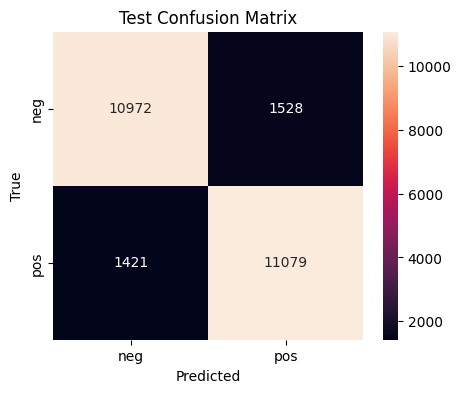

In [ ]:
#Name: Gaikwad Megha PRN:20230802376
y_val_pred = clf.predict(X_val_vec)
y_test_pred = clf.predict(X_test_vec)

print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("Test accuracy:", accuracy_score(df_test['label'].values, y_test_pred))
print("\nValidation classification report:\n", classification_report(y_val, y_val_pred, digits=4))

import seaborn as sns
cm = confusion_matrix(df_test['label'].values, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title('Test Confusion Matrix')
plt.show()


In [9]:
import gradio as gr
import json
import numpy as np

def gr_predict(review_text):
    import re
    def clean_text_local(s):
        s = s.lower()
        s = re.sub(r"http\S+", " ", s)
        s = re.sub(r"\S+@\S+", " ", s)
        s = re.sub(r"[^a-z0-9\s']", " ", s)
        s = re.sub(r"\s+", " ", s).strip()
        return s

    cleaned = clean_text_local(review_text)
    vec = tfidf.transform([cleaned])

    pred = clf.predict(vec)[0]
    label = "positive" if pred == 1 else "negative"

    try:
        prob = clf.predict_proba(vec)[0][1]
        prob = float(prob)
    except:
        prob = "n/a"

    return label, str(prob)

label_out = gr.Textbox(label="Predicted label")
prob_out  = gr.Textbox(label="Probability (positive)")

ui = gr.Interface(
    fn=gr_predict,
    inputs=gr.Textbox(placeholder="Type a movie review here...", lines=5),
    outputs=[label_out, prob_out],
    title="Movie Review Sentiment Classifier",
    description="Predict sentiment.",
    allow_flagging='never'
)

ui.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://da16871366a7593f0e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


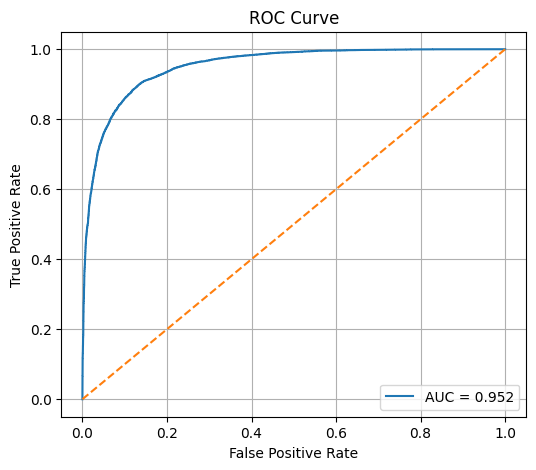

In [ ]:
#Name: Gaikwad Megha PRN:20230802376
from sklearn.metrics import roc_curve, auc

y_prob = clf.predict_proba(X_test_vec)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()


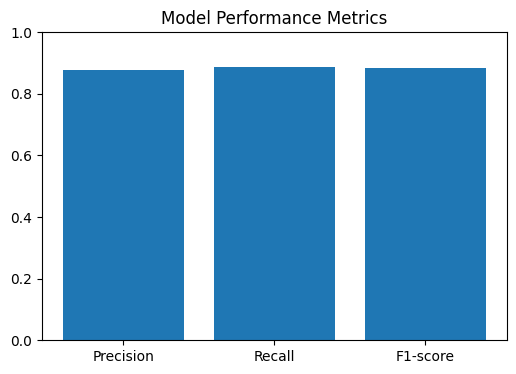

In [ ]:
#Name: Gaikwad Megha PRN:20230802376
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

plt.figure(figsize=(6,4))
plt.bar(["Precision", "Recall", "F1-score"], [precision, recall, f1])
plt.ylim(0,1)
plt.title("Model Performance Metrics")
plt.show()